✅ Bibliotecas importadas com sucesso!
✅ Dataset criado! Shape: (50, 9)


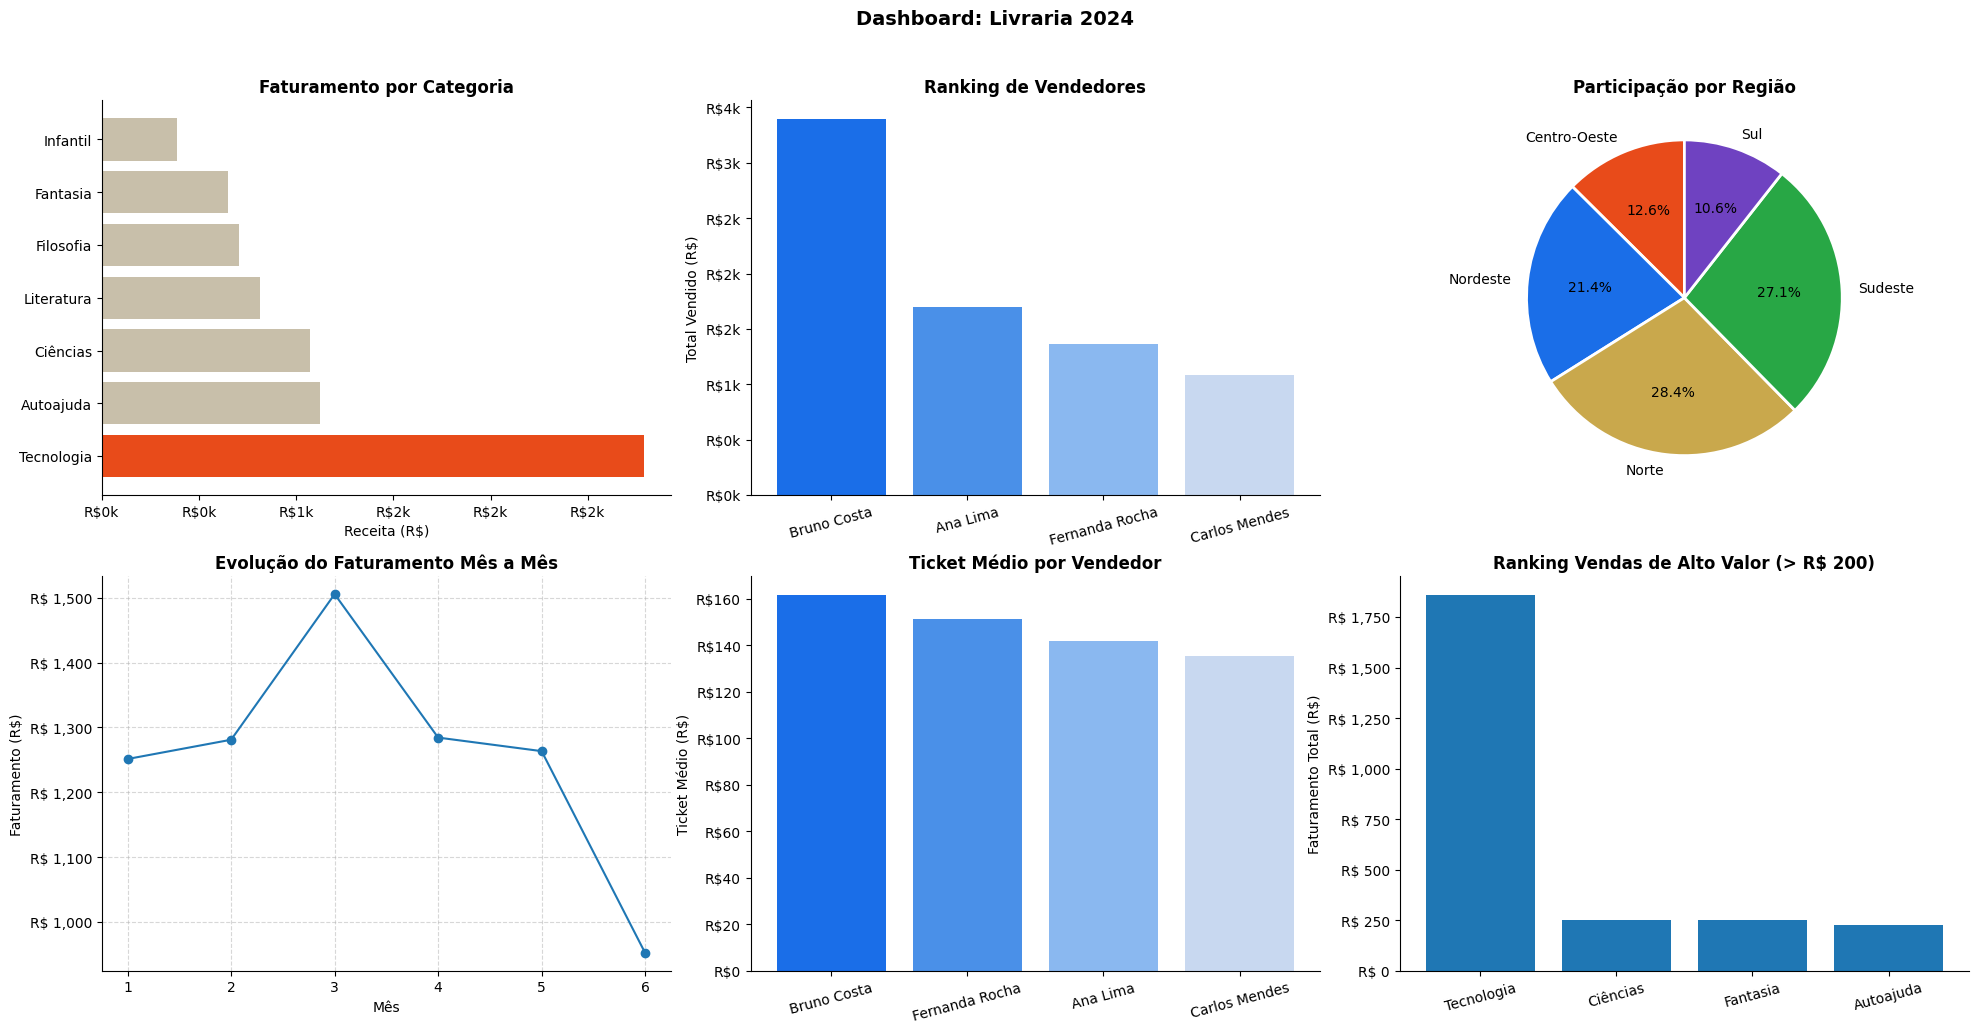

✅ Gráficos salvos em dashboard_livraria.png
✅ Linhas nulas adicionadas. Novo shape: (55, 10)
Valores nulos por coluna:
id_venda       0
data           5
produto        5
categoria      5
quantidade     5
preco_unit     5
vendedor       5
regiao         5
total_venda    5
mes            5
dtype: int64

📋 Linhas com valores nulos:
    id_venda data produto categoria  quantidade  preco_unit vendedor regiao  \
50        51  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
51        52  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
52        53  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
53        54  NaT     NaN       NaN         NaN         NaN      NaN    NaN   
54        55  NaT     NaN       NaN         NaN         NaN      NaN    NaN   

    total_venda  mes  
50          NaN  NaN  
51          NaN  NaN  
52          NaN  NaN  
53          NaN  NaN  
54          NaN  NaN  
✅ Nulos preenchidos:
    id_venda       data            

/tmp/ipykernel_3723/2092413628.py:217: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, linhas_nulas], ignore_index=True)


In [ ]:
# ── Importações ──────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Bibliotecas importadas com sucesso!")

# ── Criação do Dataset ───────────────────────────────
np.random.seed(42)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":             ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]
datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

# Salva como CSV
df.to_csv("vendas_livraria.csv", index=False)

print(f"✅ Dataset criado! Shape: {df.shape}")
#print(f"   Colunas: {list(df.columns)}")
df.head()

# ── Exploração Inicial ───────────────────────────────
"""df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("📋 INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\n📊 TIPOS DE DADOS:")
print(df.dtypes)

print("\n🔍 VALORES NULOS:")
print(df.isnull().sum())

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)"""

# ── Análise de Vendas ────────────────────────────────

# 1. Total faturado
"""total = df["total_venda"].sum()
print(f"💰 Faturamento Total: R$ {total:,.2f}")

# 2. Faturamento por categoria
print("\n📦 Faturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

# 3. Melhor vendedor
print("\n🏆 Ranking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

# 4. Produto mais vendido (em quantidade)
print("\n📚 Top 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

# 5. Venda média por região
print("\n🗺️  Ticket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))"""

# ── Visualizações ────────────────────────────────────
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20,10))
fig.suptitle("Dashboard: Livraria 2024",
             fontsize=14, fontweight="bold", y=1.02)

# --- Gráfico 1: Faturamento por Categoria (barras) ---
ax1 = axes[0, 0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

# --- Gráfico 2: Ranking Vendedores (barras verticais) ---
ax2 = axes[0, 1]
ax2.bar(vend_rank.index, vend_rank.values,
        color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=15)

# --- Gráfico 3: Distribuição das Regiões (pizza) ---
ax3 = axes[0, 2]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index,
        autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90,
        wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

# --- Gráfico 4: Evolução do Faturamento mes a mes ---

ax4 = axes[1, 0]
ax4.set_title("Evolução do Faturamento Mês a Mês", fontweight="bold")
ax4.set_xlabel("Mês")
ax4.set_ylabel("Faturamento (R$)")

df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.month

fat_mes = df.groupby("mes")["total_venda"].sum().sort_index()

ax4.plot(fat_mes.index, fat_mes.values, marker="o")
ax4.yaxis.set_major_formatter(
    mticker.StrMethodFormatter("R$ {x:,.0f}")
)

ax4.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()
fig.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")

# --- Gráfico 5: Ranking Ticket Medio ---

ticket_medio = df.groupby("vendedor").agg(
    total_vendido=("total_venda", "sum"),
    qtd_vendas=("id_venda", "count")
)

ticket_medio["ticket_medio"] = ticket_medio["total_vendido"] / ticket_medio["qtd_vendas"]
ticket_medio = ticket_medio.sort_values("ticket_medio", ascending=False)


ax5 = axes[1, 1]
ax5.bar(ticket_medio.index, ticket_medio["ticket_medio"], color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax5.set_title("Ticket Médio por Vendedor", fontweight="bold")
ax5.set_ylabel("Ticket Médio (R$)")
ax5.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y:,.0f}")
)
ax5.tick_params(axis="x", rotation=15)

# --- Gráfico 6: Vendas por Categorias > 200 ---

vendas_alto_valor = df[df["total_venda"] > 200]
cat_alto_valor = vendas_alto_valor.groupby("categoria")["total_venda"].sum().sort_values(ascending=False)

ax6 = axes[1, 2]
ax6.bar(cat_alto_valor.index, cat_alto_valor.values)
ax6.set_title("Ranking Vendas de Alto Valor (> R$ 200)", fontweight="bold")
ax6.set_ylabel("Faturamento Total (R$)")
ax6.yaxis.set_major_formatter(
    mticker.StrMethodFormatter("R$ {x:,.0f}"))
ax6.tick_params(axis="x", rotation=15)

plt.show()
print("✅ Gráficos salvos em dashboard_livraria.png")

# Criar 5 linhas com valores nulos
linhas_nulas = pd.DataFrame({
    "id_venda": [51, 52, 53, 54, 55],
    "data": [np.nan]*5,
    "produto": [np.nan]*5,
    "categoria": [np.nan]*5,
    "quantidade": [np.nan]*5,
    "preco_unit": [np.nan]*5,
    "vendedor": [np.nan]*5,
    "regiao": [np.nan]*5,
    "total_venda": [np.nan]*5
})

# Adicionar ao dataset original
df = pd.concat([df, linhas_nulas], ignore_index=True)

print("✅ Linhas nulas adicionadas. Novo shape:", df.shape)

# Ver total de valores nulos por coluna
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Mostrar linhas que possuem pelo menos um valor nulo
print("\n📋 Linhas com valores nulos:")
print(df[df.isnull().any(axis=1)])

# Preencher nulos com valores padrão
df_filled = df.fillna({
    "data": pd.Timestamp("2099-01-01"),  # data padrão
    "produto": "Produto Desconhecido",
    "categoria": "Categoria Desconhecida",
    "quantidade": 1,
    "preco_unit": 0.0,
    "vendedor": "Vendedor Desconhecido",
    "regiao": "Região Desconhecida",
    "total_venda": 0.0
})

print("✅ Nulos preenchidos:")
print(df_filled.tail(5))

# Excluir linhas que possuem qualquer valor nulo
df_dropped = df.dropna()

print("✅ Linhas com nulos removidas. Novo shape:", df_dropped.shape)